In [1]:
import pandas as pd

df = pd.read_csv("../dataset/online_food_delivery_synthetic_dataset.csv")

In [2]:
df.head()

,Order_ID,Order_Date,Customer_ID,City,Restaurant,Food_Category,Quantity,Price,Discount,Delivery_Fee,Payment_Method,Order_Status,Rating,Total_Amount
0,ORD00833,2025-01-01,CUST0085,Mumbai,Bombay Bites,Chinese,1,296.52,42.42,40,Debit Card,Cancelled,3.6,294.10
1,ORD00324,2025-01-01,CUST0112,Chennai,Chennai Bites,Chinese,1,276.98,31.58,20,Credit Card,Delivered,3.8,265.40
2,ORD00528,2025-01-01,CUST0734,Pune,Deccan Kitchen,Chinese,2,319.65,44.24,20,Credit Card,Delivered,3.8,615.06
3,ORD02437,2025-01-01,CUST0167,Pune,Deccan Kitchen,Healthy Food,2,259.21,30.53,60,UPI,Delivered,4.5,547.89
4,ORD01444,2025-01-01,CUST0146,Chennai,Spice Hub,Pizza,1,454.31,46.88,40,Credit Card,Delivered,4.8,447.43


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        3010 non-null   str    
 1   Order_Date      3010 non-null   str    
 2   Customer_ID     3010 non-null   str    
 3   City            3010 non-null   str    
 4   Restaurant      3010 non-null   str    
 5   Food_Category   3010 non-null   str    
 6   Quantity        3010 non-null   int64  
 7   Price           3010 non-null   float64
 8   Discount        3010 non-null   float64
 9   Delivery_Fee    3010 non-null   int64  
 10  Payment_Method  2985 non-null   str    
 11  Order_Status    3010 non-null   str    
 12  Rating          2949 non-null   float64
 13  Total_Amount    3010 non-null   float64
dtypes: float64(4), int64(2), str(8)
memory usage: 532.1 KB


,Quantity,Price,Discount,Delivery_Fee,Rating,Total_Amount
count,3010.000000,3010.000000,3010.000000,3010.000000,2949.000000,3010.000000
mean,1.612625,261.251618,42.455123,34.508306,4.090268,412.451814
std,0.823452,82.026271,38.968215,11.634775,0.529737,234.966255
min,1.000000,63.680000,0.020000,20.000000,2.100000,95.690000
25%,1.000000,196.410000,15.832500,20.000000,3.700000,249.120000
50%,1.000000,256.395000,31.395000,30.000000,4.100000,338.105000
75%,2.000000,318.982500,55.592500,40.000000,4.500000,520.012500
max,4.000000,570.200000,250.000000,60.000000,5.000000,1890.960000


In [4]:
df.isnull().sum()

Order_ID           0
Order_Date         0
Customer_ID        0
City               0
Restaurant         0
Food_Category      0
Quantity           0
Price              0
Discount           0
Delivery_Fee       0
Payment_Method    25
Order_Status       0
Rating            61
Total_Amount       0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(10)

In [6]:
df = df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df[df['Quantity'] <= 0]

,Order_ID,Order_Date,Customer_ID,City,Restaurant,Food_Category,Quantity,Price,Discount,Delivery_Fee,Payment_Method,Order_Status,Rating,Total_Amount


In [9]:
df[df['Price'] < 0]

,Order_ID,Order_Date,Customer_ID,City,Restaurant,Food_Category,Quantity,Price,Discount,Delivery_Fee,Payment_Method,Order_Status,Rating,Total_Amount


In [10]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [11]:
df['Total_Sales'] = df['Quantity'] * df['Price']

In [12]:
df['Total_Sales'].sum()

np.float64(1260660.2999999998)

In [13]:
df['Order_ID'].nunique()

3000

In [14]:
df['Total_Sales'].mean()

np.float64(420.22009999999995)

In [15]:
df.groupby('City')['Total_Sales'].sum()

City
Bengaluru    192230.56
Chennai      181518.46
Delhi        186489.08
Hyderabad    167831.44
Kochi        118807.12
Kolkata      107843.03
Mumbai       182180.55
Pune         123760.06
Name: Total_Sales, dtype: float64

In [16]:
df.groupby('Food_Category')['Total_Sales'].sum()

Food_Category
Biryani         233481.05
Burgers         118602.92
Chinese         178810.68
Desserts         57936.77
Healthy Food    100970.00
North Indian    193814.39
Pizza           240752.94
South Indian    136291.55
Name: Total_Sales, dtype: float64

In [17]:
df.groupby('Restaurant')['Total_Sales'].sum()

Restaurant
Bengal Feast       30503.76
Bengaluru Bowl     51174.29
Biryani Corner     28885.21
Biryani Point      37088.32
Bombay Bites       41708.91
Cafe Central       29203.34
Capital Bites      45131.96
Chennai Bites      44388.02
Coastal Kitchen    42198.80
Coastal Treats     27161.56
Coconut Cafe       36367.68
Deccan Delights    44144.27
Deccan Kitchen     28369.09
Delhi Zaika        54956.28
Dosa House         46483.12
East Spice         26470.61
Garden Kitchen     40181.34
Hyderabad House    43606.36
Kerala Kitchen     24102.87
Kolkata Kitchen    21983.45
Malabar Bites      31175.01
Marathi Meals      32500.41
Mumbai Masala      53075.82
Nawab Kitchen      42992.49
Pune Pantry        33687.22
Punjabi Rasoi      48959.94
South Spice        53960.86
Spice Hub          43429.49
Street Feast       37440.90
Tandoor Tales      45197.02
Tech Tadka         46914.07
Urban Tiffin       47217.83
Name: Total_Sales, dtype: float64

In [18]:
df.groupby(
    df['Order_Date'].dt.to_period('M')
)['Total_Sales'].sum()

Order_Date
2025-01     98055.77
2025-02     97474.63
2025-03    101538.68
2025-04    111360.26
2025-05    112987.40
2025-06    108291.73
2025-07    109994.82
2025-08    103193.54
2025-09    105275.77
2025-10     99164.35
2025-11    104537.90
2025-12    108785.45
Freq: M, Name: Total_Sales, dtype: float64

In [19]:
df.select_dtypes(include='number').corr()

,Quantity,Price,Discount,Delivery_Fee,Rating,Total_Amount,Total_Sales
Quantity,1.000000,-0.013901,0.563858,0.019859,0.005219,0.811266,0.817891
Price,-0.013901,1.000000,0.328938,-0.010268,-0.003910,0.496931,0.499524
Discount,0.563858,0.328938,1.000000,-0.011403,0.015507,0.593511,0.687720
Delivery_Fee,0.019859,-0.010268,-0.011403,1.000000,-0.001732,0.059660,0.007503
Rating,0.005219,-0.003910,0.015507,-0.001732,1.000000,0.008015,0.009672
Total_Amount,0.811266,0.496931,0.593511,0.059660,0.008015,1.000000,0.991349
Total_Sales,0.817891,0.499524,0.687720,0.007503,0.009672,0.991349,1.000000


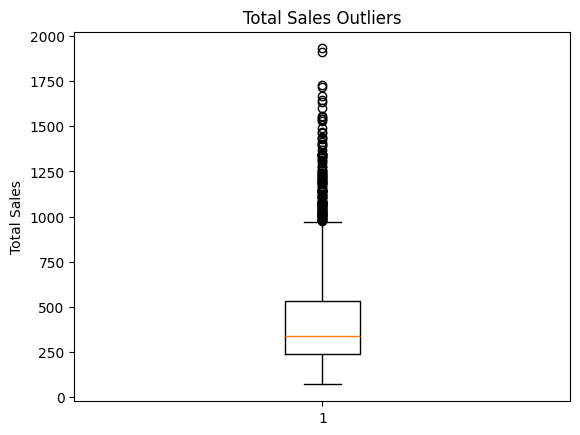

In [20]:
import matplotlib.pyplot as plt

plt.boxplot(df['Total_Sales'])
plt.title('Total Sales Outliers')
plt.ylabel('Total Sales')
plt.show()